In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import importlib

%matplotlib inline

sys.path.append("/Users/ppopov1/DECIFRA/scripts/asset_scripts/scripts")
import plot_connectograms as pc
importlib.reload(pc)

<module 'plot_connectograms' from '/Users/ppopov1/DECIFRA/scripts/asset_scripts/scripts/plot_connectograms.py'>

In [2]:
# Load mapping components from structural definition CSV
csv_path = "/Users/ppopov1/DECIFRA/assets/data/ICN_coordinates_refined.csv"
(
    ordered_indices, ordered_names, ordered_colors, 
    domain_to_indices, unique_domains, domain_to_color
) = pc.get_domain_data(csv_path)

# -----------------------------------------------------
# EXTRACTION BLOCK FOR ARBITRARY DATA PLOTTING
# -----------------------------------------------------

# 1. Select the original dataset array to plot 
# (Replace randomly with your own matrix directly!)
target_matrix_name = "SZ_C"
matrix_data = np.load(f"/Users/ppopov1/DECIFRA/assets/data/patterns/recovered_matrices/{target_matrix_name}.npy")[::-1, :]

# 2. Regional Data & Tick Labels
# Reorder any raw matrix explicitly to line up accurately with CSV structural regions:
region_data = matrix_data[np.ix_(ordered_indices, ordered_indices)]
region_labels = ordered_names
region_colors = ordered_colors

# 3. Domain Data & Tick Labels
# Map blocks dynamically directly to their macroscopic domains:
domain_data = pc.aggregate_domain_matrix(matrix_data, ordered_indices, domain_to_indices, unique_domains)
domain_labels = unique_domains
domain_colors = [domain_to_color[d] for d in unique_domains]

print("Variables globally instantiated for direct granular manipulation!")

Variables globally instantiated for direct granular manipulation!


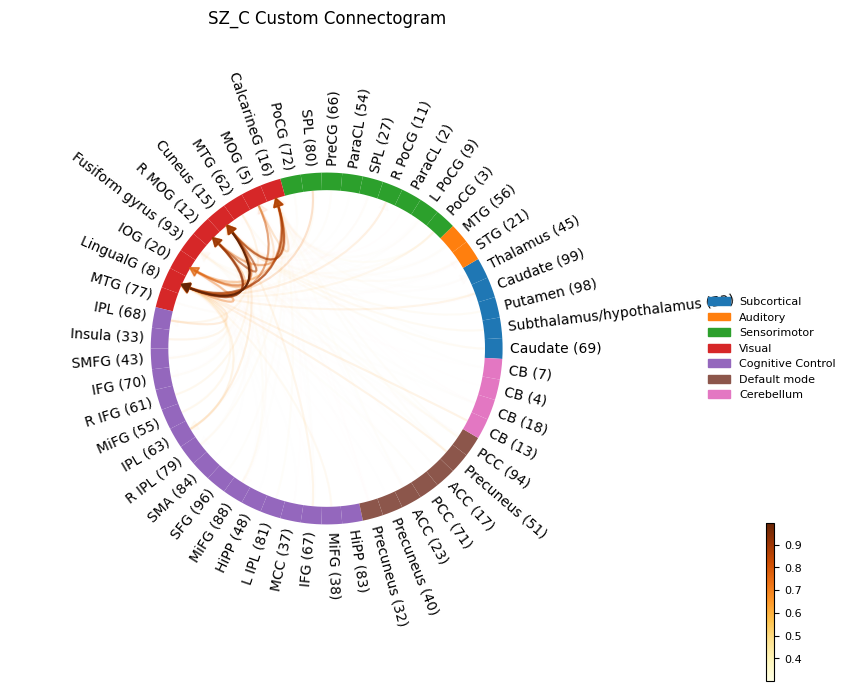

In [3]:
# Universal Function 1: Plot arbitrary region matrices natively
legend_patches = [mpatches.Patch(color=domain_to_color[d], label=d) for d in unique_domains]

fig_region, ax_region = pc.plot_connectogram(
    matrix = region_data,
    node_names = region_labels,
    node_colors = region_colors,
    title = f"{target_matrix_name} Custom Connectogram",
    cmap = 'YlOrBr',
    threshold_percentile = 90,     # Filters visually weak off-diagonal boundaries directly via percentile array rank
    legend_patches = legend_patches,
    fontsize_names=10
)
plt.show()

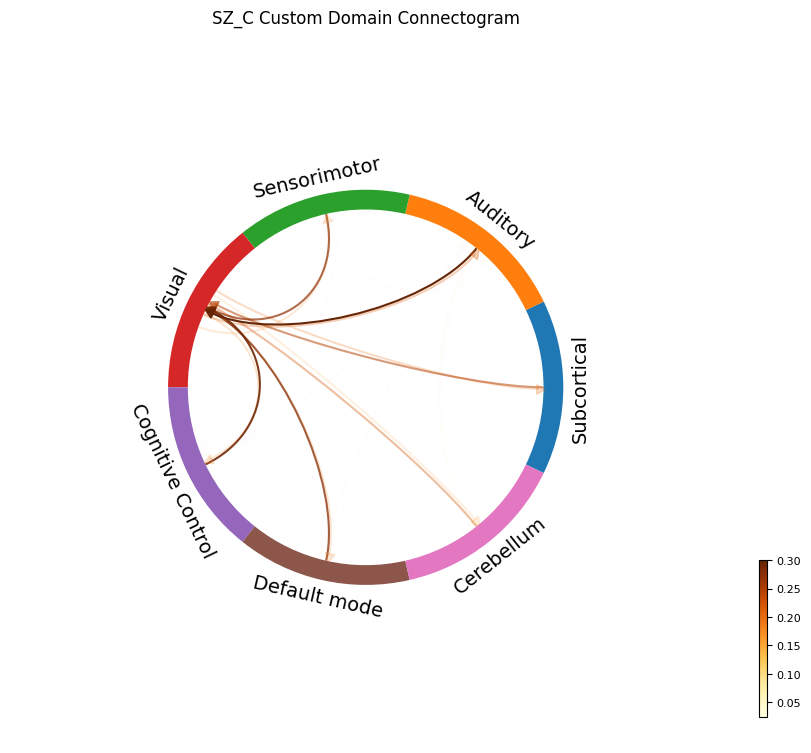

In [ ]:
# Universal Function 2: Plot arbitrary domain matrices across exactly the same engine flexibly! 
fig_dom, ax_dom = pc.plot_connectogram(
    matrix = domain_data,
    node_names = domain_labels,
    node_colors = domain_colors,
    title = f"{target_matrix_name} Custom Domain Connectogram",
    cmap = 'YlOrBr',
    threshold_percentile = 0,     # Enforces structural threshold parity
    fontsize_names=14,
    rotate_labels_90=True          # Flips structural spacing natively embedding text onto parallel orbit paths natively
)
plt.show()

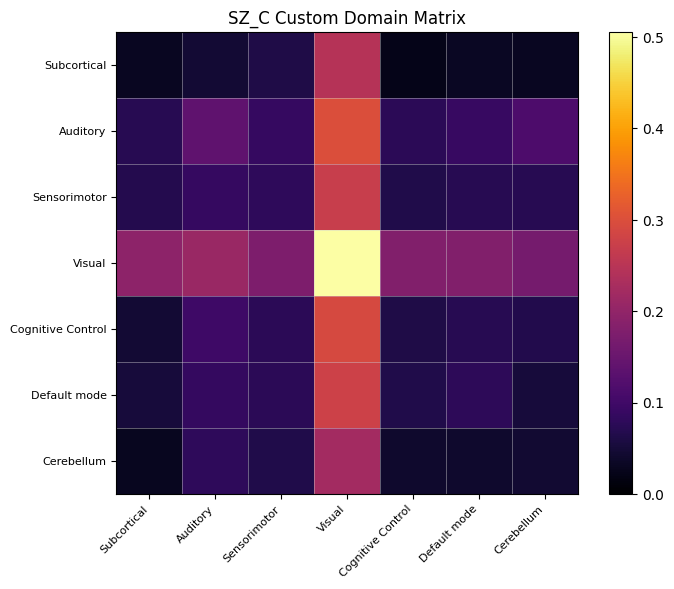

In [13]:
# Universal Function 3: Raw 2D Structural Plotting
fig_mat, ax_mat = pc.plot_matrix_heatmap(
    matrix = domain_data,
    node_names = domain_labels,
    title = f"{target_matrix_name} Custom Domain Matrix",
    threshold_percentile = 0      # Drops bottom percentile data explicitly to 0.0 structurally
)
plt.show()

In [3]:
import os
import glob

# Identify all `.npy` files to batch process
matrix_files = glob.glob("/Users/ppopov1/DECIFRA/assets/data/patterns/recovered_matrices/*.npy")
output_dir = "/Users/ppopov1/DECIFRA/assets/data/patterns/connectograms/"
os.makedirs(output_dir, exist_ok=True)

# Loop over all matrices automatically producing 3 plots each
for filepath in matrix_files:
    target_matrix_name = os.path.basename(filepath).replace(".npy", "")
    print(f"Processing: {target_matrix_name}...")
    
    matrix_data = np.load(filepath)[::-1, :]
    
    # Structure mapping 
    region_data = matrix_data[np.ix_(ordered_indices, ordered_indices)]
    domain_data = pc.aggregate_domain_matrix(matrix_data, ordered_indices, domain_to_indices, unique_domains)
    legend_patches = [mpatches.Patch(color=domain_to_color[d], label=d) for d in unique_domains]
    
    # 1. Full Connectogram (Using exact settings you manually created)
    fig_region, _ = pc.plot_connectogram(
        matrix=region_data, node_names=ordered_names, node_colors=ordered_colors,
        title=f"{target_matrix_name} Custom Connectogram", cmap="YlOrBr",
        threshold_percentile=90, legend_patches=legend_patches, fontsize_names=10,
        vmin=0
    )
    fig_region.savefig(f"{output_dir}{target_matrix_name}_region.svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_region)

    # 2. Domain Connectogram
    fig_dom, _ = pc.plot_connectogram(
        matrix=domain_data, node_names=unique_domains, node_colors=[domain_to_color[d] for d in unique_domains],
        title=f"{target_matrix_name} Custom Domain Connectogram", cmap="YlOrBr",
        threshold_percentile=0, fontsize_names=19,
        linewidth=10,
        # rotate_labels_90=True, 
    )
    fig_dom.savefig(f"{output_dir}{target_matrix_name}_domain.svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_dom)

    break

print("Batch processing complete!")

Processing: SZ_C...
Batch processing complete!


In [4]:
import os
import glob

# Identify all `.npy` files to batch process
matrix_files = glob.glob("/Users/ppopov1/DECIFRA/assets/data/patterns/recovered_matrices/*.npy")
output_dir = "/Users/ppopov1/DECIFRA/assets/data/patterns/connectograms/"
os.makedirs(output_dir, exist_ok=True)

# Loop over all matrices automatically producing 3 plots each
for filepath in matrix_files:
    target_matrix_name = os.path.basename(filepath).replace(".npy", "")
    print(f"Processing: {target_matrix_name}...")
    
    matrix_data = np.load(filepath)[::-1, :]
    
    # Structure mapping 
    region_data = matrix_data[np.ix_(ordered_indices, ordered_indices)]
    domain_data = pc.aggregate_domain_matrix(matrix_data, ordered_indices, domain_to_indices, unique_domains)
    legend_patches = [mpatches.Patch(color=domain_to_color[d], label=d) for d in unique_domains]
    
    # 1. Full Connectogram (Using exact settings you manually created)
    fig_region, _ = pc.plot_connectogram(
        matrix=region_data, node_names=ordered_names, node_colors=ordered_colors,
        title=f"{target_matrix_name} Custom Connectogram", cmap="YlOrBr",
        threshold_percentile=90, legend_patches=legend_patches, fontsize_names=10,
        vmin=0, hide_misc=True
    )
    fig_region.savefig(f"{output_dir}{target_matrix_name}_region.svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_region)

    # 2. Domain Connectogram
    fig_dom, _ = pc.plot_connectogram(
        matrix=domain_data, node_names=unique_domains, node_colors=[domain_to_color[d] for d in unique_domains],
        title=f"{target_matrix_name} Custom Domain Connectogram", cmap="YlOrBr",
        threshold_percentile=0, fontsize_names=19, rotate_labels_90=True, 
        linewidth=10, hide_misc=True
    )
    fig_dom.savefig(f"{output_dir}{target_matrix_name}_domain.svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig_dom)

    break

print("Batch processing complete!")

Processing: SZ_C...
Batch processing complete!


In [7]:
sys.path.append("/Users/ppopov1/DECIFRA/scripts/asset_scripts/scripts")
import plot_connectograms as pc
importlib.reload(pc)

import os
import glob

# Identify all `.npy` files to batch process
matrix_file = "/Users/ppopov1/DECIFRA/assets/data/patterns/recovered_matrices/SZ_C.npy"
output_dir = "/Users/ppopov1/DECIFRA/assets/data/patterns/connectograms/"
os.makedirs(output_dir, exist_ok=True)

target_matrix_name = os.path.basename(matrix_file).replace(".npy", "")
print(f"Processing: {target_matrix_name}...")
matrix_data = np.load(matrix_file)[::-1, :]

region_data = matrix_data[np.ix_(ordered_indices, ordered_indices)]
domain_data = pc.aggregate_domain_matrix(matrix_data, ordered_indices, domain_to_indices, unique_domains)
legend_patches = [mpatches.Patch(color=domain_to_color[d], label=d) for d in unique_domains]

# 1. Full Connectogram (Using exact settings you manually created)
fig_region, _ = pc.plot_connectogram(
    matrix=region_data, node_names=ordered_names, node_colors=ordered_colors,
    title=f"New Connectogram 1", cmap="YlOrBr",
    threshold_percentile=90, fontsize_names=10,
    vmin=0
)
fig_region.savefig(f"{output_dir}new_1.png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig_region)

# 2. Domain Connectogram
fig_dom, _ = pc.plot_connectogram(
    matrix=domain_data, node_names=unique_domains, node_colors=[domain_to_color[d] for d in unique_domains],
    title=f"New Connectogram 2", cmap="YlOrBr",
    threshold_percentile=0, fontsize_names=12, rotate_labels_90=True, 
    linewidth=10
)
fig_dom.savefig(f"{output_dir}new_2.png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig_dom)

Processing: SZ_C...


In [3]:
sys.path.append("/Users/ppopov1/DECIFRA/scripts/asset_scripts/scripts")
import plot_connectograms as pc
importlib.reload(pc)

import os
import glob

# Identify all `.npy` files to batch process
matrix_file = "/Users/ppopov1/DECIFRA/assets/data/patterns/recovered_matrices/SZ_C.npy"
output_dir = "/Users/ppopov1/DECIFRA/assets/data/patterns/connectograms/"
os.makedirs(output_dir, exist_ok=True)

target_matrix_name = os.path.basename(matrix_file).replace(".npy", "")
print(f"Processing: {target_matrix_name}...")
matrix_data = np.load(matrix_file)[::-1, :]

region_data = matrix_data[np.ix_(ordered_indices, ordered_indices)]
domain_data = pc.aggregate_domain_matrix(matrix_data, ordered_indices, domain_to_indices, unique_domains)
legend_patches = [mpatches.Patch(color=domain_to_color[d], label=d) for d in unique_domains]

# 1. Full Connectogram (Using exact settings you manually created)
fig_region, _ = pc.plot_connectogram(
    matrix=region_data, node_names=ordered_names, node_colors=ordered_colors,
    title=f"Old Connectogram 1", cmap="YlOrBr",
    threshold_percentile=90, fontsize_names=10,
    vmin=0
)
fig_region.savefig(f"{output_dir}old_1.png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig_region)

# 2. Domain Connectogram
fig_dom, _ = pc.plot_connectogram(
    matrix=domain_data, node_names=unique_domains, node_colors=[domain_to_color[d] for d in unique_domains],
    title=f"Old Connectogram 2", cmap="YlOrBr",
    threshold_percentile=0, fontsize_names=12, rotate_labels_90=True, 
    linewidth=10
)
fig_dom.savefig(f"{output_dir}old_2.png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig_dom)

Processing: SZ_C...
